In [ ]:
!pip install netcdf4 h5netcdf xarray spicy tables geopandas shapely rasterio rioxarray --upgrade

In [3]:
import numpy as np
import pandas as pd
import scipy
import glob
import h5py
import h5netcdf
import netCDF4 as nc
import xarray as xr
import rioxarray as rio
import os
import re
from joblib import Parallel, delayed
import geopandas as gpd
from shapely.geometry import Point, LineString, Polygon  # Import relevant geometry types
import rasterio
from rasterio.transform import from_origin
from rasterio.features import rasterize
from osgeo import gdal, ogr

xr.backends.refresh_engines()
print(xr.backends.list_engines())

{'netcdf4': <NetCDF4BackendEntrypoint>
  Open netCDF (.nc, .nc4 and .cdf) and most HDF5 files using netCDF4 in Xarray
  Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.NetCDF4BackendEntrypoint.html, 'h5netcdf': <H5netcdfBackendEntrypoint>
  Open netCDF (.nc, .nc4 and .cdf) and most HDF5 files using h5netcdf in Xarray
  Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.H5netcdfBackendEntrypoint.html, 'scipy': <ScipyBackendEntrypoint>
  Open netCDF files (.nc, .nc4, .cdf and .gz) using scipy in Xarray
  Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.ScipyBackendEntrypoint.html, 'rasterio': <RasterioBackend>, 'store': <StoreBackendEntrypoint>
  Open AbstractDataStore instances in Xarray
  Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.StoreBackendEntrypoint.html}


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
idw_path_year = "/content/drive/MyDrive/BRain-D/Scripts e Dados/1 - Organized data gauge/BRAZIL/INTERPOLATION/YEARLY"
idw_path_decade = "/content/drive/MyDrive/BRain-D/Scripts e Dados/1 - Organized data gauge/BRAZIL/INTERPOLATION/DECADE"
idw_path_total = "/content/drive/MyDrive/BRain-D/Scripts e Dados/1 - Organized data gauge/BRAZIL/INTERPOLATION"

# Decade grouping

In [6]:
all_files = glob.glob(idw_path_year + r"/*.h5")
total_length = len(all_files)
print(total_length)
all_files.sort()
all_files

64


['/content/drive/MyDrive/BRain-D/Scripts e Dados/1 - Organized data gauge/BRAZIL/INTERPOLATION/YEARLY/precipitation_idw_1961.h5',
 '/content/drive/MyDrive/BRain-D/Scripts e Dados/1 - Organized data gauge/BRAZIL/INTERPOLATION/YEARLY/precipitation_idw_1962.h5',
 '/content/drive/MyDrive/BRain-D/Scripts e Dados/1 - Organized data gauge/BRAZIL/INTERPOLATION/YEARLY/precipitation_idw_1963.h5',
 '/content/drive/MyDrive/BRain-D/Scripts e Dados/1 - Organized data gauge/BRAZIL/INTERPOLATION/YEARLY/precipitation_idw_1964.h5',
 '/content/drive/MyDrive/BRain-D/Scripts e Dados/1 - Organized data gauge/BRAZIL/INTERPOLATION/YEARLY/precipitation_idw_1965.h5',
 '/content/drive/MyDrive/BRain-D/Scripts e Dados/1 - Organized data gauge/BRAZIL/INTERPOLATION/YEARLY/precipitation_idw_1966.h5',
 '/content/drive/MyDrive/BRain-D/Scripts e Dados/1 - Organized data gauge/BRAZIL/INTERPOLATION/YEARLY/precipitation_idw_1967.h5',
 '/content/drive/MyDrive/BRain-D/Scripts e Dados/1 - Organized data gauge/BRAZIL/INTERPOLA

In [8]:
decade_dict = {}

# Process each file in the list
for file in all_files[:]:
    # Use regex to extract the decade from the filename; assumes pattern "yyyy-mm-dd.nc" at the end.
    match = re.search(r'(\d{4}).h5$', file)
    if match:
        decade = (int(match.group(1))-1 ) // 10 * 10
        # Initialize list if the key does not exist
        if decade not in decade_dict:
            decade_dict[decade] = []
        # Append the file to the appropriate decade list
        decade_dict[decade].append(file)

# If you want the result as a list of lists sorted by decade:
decade_file_lists = [decade_dict[d] for d in sorted(decade_dict)]
# print(decade_file_lists[0])

# Alternatively, print the dictionary with decade labels:
for decade in sorted(decade_dict):
    print(f"list_{decade}: {len(decade_dict[decade])} files; {decade_dict[decade]}")

list_1960: 10 files; ['/content/drive/MyDrive/BRain-D/Scripts e Dados/1 - Organized data gauge/BRAZIL/INTERPOLATION/YEARLY/precipitation_idw_1961.h5', '/content/drive/MyDrive/BRain-D/Scripts e Dados/1 - Organized data gauge/BRAZIL/INTERPOLATION/YEARLY/precipitation_idw_1962.h5', '/content/drive/MyDrive/BRain-D/Scripts e Dados/1 - Organized data gauge/BRAZIL/INTERPOLATION/YEARLY/precipitation_idw_1963.h5', '/content/drive/MyDrive/BRain-D/Scripts e Dados/1 - Organized data gauge/BRAZIL/INTERPOLATION/YEARLY/precipitation_idw_1964.h5', '/content/drive/MyDrive/BRain-D/Scripts e Dados/1 - Organized data gauge/BRAZIL/INTERPOLATION/YEARLY/precipitation_idw_1965.h5', '/content/drive/MyDrive/BRain-D/Scripts e Dados/1 - Organized data gauge/BRAZIL/INTERPOLATION/YEARLY/precipitation_idw_1966.h5', '/content/drive/MyDrive/BRain-D/Scripts e Dados/1 - Organized data gauge/BRAZIL/INTERPOLATION/YEARLY/precipitation_idw_1967.h5', '/content/drive/MyDrive/BRain-D/Scripts e Dados/1 - Organized data gauge/BR

In [ ]:
# decades = []
# for filename in os.listdir(idw_path_decade + r"/"):
#     if filename.endswith(r".nc"):
#         match = re.search(r'_(\d{4})\.nc$', filename)
#         if match:
#             decades.append(int(match.group(1)))
# decades

In [ ]:
# decades.pop(-3)

## VERIFY LAST FILE

In [ ]:
# decade_dict = {key: value for key, value in decade_dict.items() if key not in decades}
# decade_dict


In [9]:
def read_file(filepath):
    return pd.read_hdf(filepath)

In [10]:
merged_datasets = {}

for decade, file_list in decade_dict.items():
    print(decade)
    # print(file_list[0])
    # if decade == 2010 or decade == 2020:
    # Open and merge all files for this year by coordinates
    df_list = Parallel(n_jobs=-1)(
            delayed(read_file)(filepath) for filepath in file_list
        )

    df_total = pd.concat(df_list)

    # Save the merged dataset to a new NetCDF file (optional)
    output_filename = idw_path_decade + f'/precipitation_idw_{decade+1}_{decade+10}.h5'
    df_total.to_hdf(output_filename
                    , key = 'table_data'
                    , append = False
                    , format = 'table'
                    , mode = 'w'
                    , complevel=9
                    , complib='blosc:lz4')
    print(f"Saved merged dataset of decade {decade} to {output_filename[-35:0]}")

1960
Saved merged dataset of decade 1960 to 
1970
Saved merged dataset of decade 1970 to 
1980
Saved merged dataset of decade 1980 to 
1990
Saved merged dataset of decade 1990 to 
2000
Saved merged dataset of decade 2000 to 
2010
Saved merged dataset of decade 2010 to 
2020
Saved merged dataset of decade 2020 to 


# Decade to netCDF

In [7]:
all_files_hdf = glob.glob(idw_path_decade + r"/*.h5")
all_files_hdf.sort()
total_length = len(all_files_hdf)
print(total_length)
all_files_hdf[0]

7


'/content/drive/MyDrive/BRain-D/Scripts e Dados/1 - Organized data gauge/BRAZIL/INTERPOLATION/DECADE/precipitation_idw_1961_1970.h5'

In [8]:
for filename in all_files_hdf[:]:
    df = pd.read_hdf(filename, key= 'table_data')
    df['lat'] = df['lat'].astype('float64').round(2)
    df['long'] = df['long'].astype('float64').round(2)
    df['datetime'] = pd.to_datetime(df['datetime'])
    # Rename columns
    df = df.rename(columns={
        'lat': 'latitude',
        'long': 'longitude',
        'rain_mm': 'pr',
        'datetime': 'date'
    })

    # Convert to xarray Dataset
    ds = xr.Dataset.from_dataframe(df.set_index(['latitude', 'longitude', 'date']))

    # Add metadata/attributes (recommended)
    ds['latitude'].attrs = {'units': 'degrees', 'long_name': 'Latitude'}
    ds['longitude'].attrs = {'units': 'degrees', 'long_name': 'Longitude'}
    ds['pr'].attrs = {
        'units': 'mm',
        'long_name': 'Precipitation',
        'description': 'Daily precipitation in millimiters'
    }

    # Set float64 for precipitation data
    encoding = {'pr': {'dtype': 'float64'}
                , 'latitude': {'dtype': 'float64'}
                , 'longitude': {'dtype': 'float64'}
                }
    file_export = filename.replace('.h5', '.nc')

    # Save to NetCDF
    ds.to_netcdf(file_export, encoding=encoding, engine = 'h5netcdf')

    ds['latitude'] = ds['latitude'].astype('float64').round(2)
    ds['longitude'] = ds['longitude'].astype('float64').round(2)


    print(f"Saved {filename[-30:]} to {file_export}")

Saved precipitation_idw_1961_1970.h5 to /content/drive/MyDrive/BRain-D/Scripts e Dados/1 - Organized data gauge/BRAZIL/INTERPOLATION/DECADE/precipitation_idw_1961_1970.nc
Saved precipitation_idw_1971_1980.h5 to /content/drive/MyDrive/BRain-D/Scripts e Dados/1 - Organized data gauge/BRAZIL/INTERPOLATION/DECADE/precipitation_idw_1971_1980.nc
Saved precipitation_idw_1981_1990.h5 to /content/drive/MyDrive/BRain-D/Scripts e Dados/1 - Organized data gauge/BRAZIL/INTERPOLATION/DECADE/precipitation_idw_1981_1990.nc
Saved precipitation_idw_1991_2000.h5 to /content/drive/MyDrive/BRain-D/Scripts e Dados/1 - Organized data gauge/BRAZIL/INTERPOLATION/DECADE/precipitation_idw_1991_2000.nc
Saved precipitation_idw_2001_2010.h5 to /content/drive/MyDrive/BRain-D/Scripts e Dados/1 - Organized data gauge/BRAZIL/INTERPOLATION/DECADE/precipitation_idw_2001_2010.nc
Saved precipitation_idw_2011_2020.h5 to /content/drive/MyDrive/BRain-D/Scripts e Dados/1 - Organized data gauge/BRAZIL/INTERPOLATION/DECADE/preci

In [9]:
df_list = []
for i in range(len(all_files_hdf)):
    print(f"{i+1}/{len(all_files_hdf)}")
    filename = all_files_hdf[i]
    df = pd.read_hdf(filename, key= 'table_data')
    df_list.append(df)
    del df
    print(f"Saved {filename[-30:]}")
df_total = pd.concat(df_list)
del df_list
df_total.to_hdf(idw_path_total+r"/precipitation_idw_1961_2024.h5"
    , key= 'table_data'
    , mode = 'w'
    , complevel=9
    , complib='blosc:lz4'
    , format = 'table'
    , append = False)
df_total

1/7
Saved precipitation_idw_1961_1970.h5
2/7
Saved precipitation_idw_1971_1980.h5
3/7
Saved precipitation_idw_1981_1990.h5
4/7
Saved precipitation_idw_1991_2000.h5
5/7
Saved precipitation_idw_2001_2010.h5
6/7
Saved precipitation_idw_2011_2020.h5
7/7
Saved precipitation_idw_2021_2024.h5


,lat,long,rain_mm,datetime
0,-33.65,-53.45,0.0,1961-01-01
1,-33.65,-53.35,0.0,1961-01-01
2,-33.65,-53.25,0.0,1961-01-01
3,-33.55,-53.45,0.0,1961-01-01
4,-33.55,-53.35,0.0,1961-01-01
...,...,...,...,...
73106,5.25,-60.15,0.0,2024-12-31
73107,5.25,-60.05,0.0,2024-12-31
73108,5.35,-60.15,0.0,2024-12-31
73109,5.35,-60.35,0.0,2024-12-31


In [10]:
del df_total

# Creating tiffs

In [ ]:
# df_total = pd.read_hdf(idw_path_total+r"/precipitation_idw_1961_2024.h5", key= 'table_data')
# df_total

,lat,long,rain_mm,datetime
0,-33.65,-53.45,0.0,1961-01-01
1,-33.65,-53.35,0.0,1961-01-01
2,-33.65,-53.25,0.0,1961-01-01
3,-33.55,-53.45,0.0,1961-01-01
4,-33.55,-53.35,0.0,1961-01-01
...,...,...,...,...
73106,5.25,-60.15,0.0,2024-12-31
73107,5.25,-60.05,0.0,2024-12-31
73108,5.35,-60.15,0.0,2024-12-31
73109,5.35,-60.35,0.0,2024-12-31


In [ ]:
# print(df_total['datetime'].min(), df_total['datetime'].max())

1961-01-01 00:00:00 2024-12-31 00:00:00


In [ ]:
# # Extract year from datetime column
# df_total['year'] = df_total['datetime'].dt.year

# # Group by year, lat, long and sum rain_mm
# df_yearly_sum = df_total.groupby(['year', 'lat', 'long'])['rain_mm'].sum().reset_index()
# df_yearly_sum

,year,lat,long,rain_mm
0,1961,-33.75,-53.55,1229.707497
1,1961,-33.75,-53.45,1221.516264
2,1961,-33.75,-53.35,1218.670692
3,1961,-33.75,-53.25,1222.801870
4,1961,-33.75,-53.15,1231.378417
...,...,...,...,...
4679099,2024,5.25,-60.15,1442.296787
4679100,2024,5.25,-60.05,1442.737737
4679101,2024,5.35,-60.35,1441.287157
4679102,2024,5.35,-60.25,1441.309638


In [ ]:
# print(df_yearly_sum['rain_mm'].min(), df_yearly_sum['rain_mm'].max())

173.77619097985828 5825.908325268719


In [ ]:
# for year in range(1961, 1962):
#     df = df_yearly_sum[df_yearly_sum['year'] == year]
#     df = df.assign(
#         lat=lambda x: x['lat'].astype('float64').round(2),
#         long=lambda x: x['long'].astype('float64').round(2)
#         )
#     # Rename columns
#     df = df.rename(columns={
#         'lat': 'latitude',
#         'long': 'longitude',
#         'rain_mm': 'pr'
#     })

#     # Convert to xarray Dataset
#     ds = xr.Dataset.from_dataframe(df.set_index(['latitude', 'longitude']))

#     # Add metadata/attributes (recommended)
#     ds['latitude'].attrs = {'units': 'degrees', 'long_name': 'Latitude'}
#     ds['longitude'].attrs = {'units': 'degrees', 'long_name': 'Longitude'}
#     ds['pr'].attrs = {
#         'units': 'mm',
#         'long_name': 'Precipitation',
#         'description': 'Daily precipitation in millimiters'
#     }

#     # Set float64 for precipitation data
#     encoding = {'pr': {'dtype': 'float64'}
#                 , 'latitude': {'dtype': 'float64'}
#                 , 'longitude': {'dtype': 'float64'}
#                 }
#     ds.to_netcdf(f"/content/drive/MyDrive/BRain-D/Scripts e Dados/1 - Organized data gauge/BRAZIL/NetCDF/IDW_annual_precip_hdf/precipitation_idw_{year}.nc", encoding=encoding)

#     pr = ds['pr']
#     pr.rio.set_spatial_dims(x_dim="longitude", y_dim="latitude", inplace=True)
#     pr.rio.write_crs("EPSG:4326", inplace=True)
#     pr.rio.to_raster(f"/content/drive/MyDrive/BRain-D/Scripts e Dados/1 - Organized data gauge/BRAZIL/NetCDF/IDW_annual_precip_hdf/output_{year}.tif")
#     print(f"Saved {year} to precipitation_idw_{year}.nc")


Saved 1961 to precipitation_idw_1961.nc


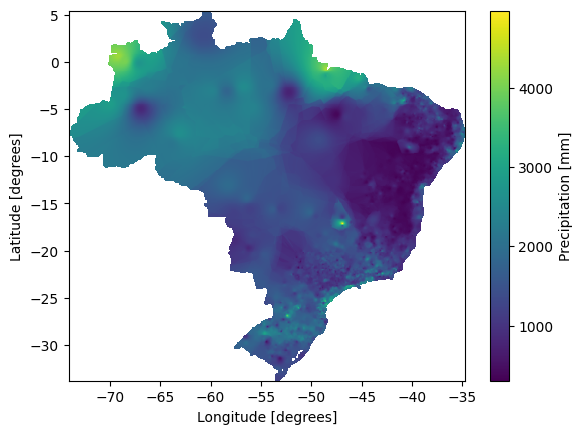

In [ ]:
# ds = xr.open_dataset(f"/content/drive/MyDrive/BRain-D/Scripts e Dados/1 - Organized data gauge/BRAZIL/NetCDF/IDW_annual_precip_hdf/precipitation_idw_1961.nc")
# pr = ds['pr']
# pr.plot()

# End processing

In [11]:
from google.colab import runtime
runtime.unassign()